# Trafic réseau

Deux colonnes qu'on a pas encore utilisées : `net_in_bytes` et `net_out_bytes`. Dans le
cloud, les données qui sortent coûtent en général plus cher que celles qui entrent.
On regarde combien de données transitent par ressource, dans quel sens, et si ça se
retrouve sur la facture.

## 1. Chargement

In [10]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df[["service", "region", "net_in_bytes", "net_out_bytes", "cost_usd"]].head()

,service,region,net_in_bytes,net_out_bytes,cost_usd
0,Cloud Dataproc,europe-north1,77097035547,8.268593e+10,5004.12
1,Pub/Sub,europe-west1,8239357017,1.135149e+10,4710.01
2,BigQuery,southamerica-east1,23358691883,2.345081e+10,843.22
3,Cloud Endpoints,us-central1,53404385778,6.078019e+10,1822.18
4,Cloud Spanner,asia-southeast1,10795270461,1.416138e+10,2046.17


## 2. Des octets aux Go

`net_in_bytes` tourne autour de 5e10, illisible. On divise par 1e9 pour passer en Go.

In [11]:
df["net_in_gb"] = df["net_in_bytes"] / 1e9
df["net_out_gb"] = df["net_out_bytes"] / 1e9
df["net_total_gb"] = df["net_in_gb"] + df["net_out_gb"]

df[["net_in_gb", "net_out_gb", "net_total_gb"]].describe().round(1)

,net_in_gb,net_out_gb,net_total_gb
count,1000.0,1000.0,1000.0
mean,51.5,56.5,108.0
std,28.3,28.4,56.6
min,1.0,1.2,2.2
25%,27.5,33.5,60.6
50%,52.6,57.8,110.2
75%,75.8,80.8,156.7
max,99.8,108.8,208.5


## 3. Sens du trafic

Dans le vrai cloud, c'est le trafic sortant qui est facturé.

In [12]:
df["part_sortant"] = df["net_out_gb"] / df["net_total_gb"]

df["part_sortant"].describe().round(3)

count    1000.000
mean        0.539
std         0.049
min         0.500
25%         0.512
50%         0.523
75%         0.543
max         0.887
Name: part_sortant, dtype: float64

In [13]:
df[["net_in_gb", "net_out_gb"]].corr().round(2)

,net_in_gb,net_out_gb
net_in_gb,1.00,0.99
net_out_gb,0.99,1.00


Le trafic est **toujours** majoritairement sortant : la part sortante ne descend
jamais sous 50 %, avec 54 % en moyenne. Et `net_in_gb` et `net_out_gb` bougent
ensemble (corrélation 0,99) : une ressource qui reçoit beaucoup émet beaucoup.

## 4. Trafic par service

In [14]:
trafic_service = df.groupby("service")["net_total_gb"].mean().sort_values()

trafic_service.round(1)

service
Firestore                94.4
Cloud Storage            95.3
Cloud Run                98.1
Dataflow                 99.7
Cloud Interconnect      101.4
Cloud Functions         102.7
BigQuery                103.5
Cloud Spanner           103.8
Kubernetes Engine       104.3
Cloud NAT               105.2
Cloud Armor             106.0
Cloud VPN               106.3
Cloud Build             107.6
Pub/Sub                 108.3
Cloud SQL               110.3
Cloud Memorystore       111.8
Cloud Load Balancing    112.8
AI Platform             114.2
Cloud CDN               114.4
Compute Engine          114.6
Container Registry      115.1
Cloud Dataproc          115.4
Cloud Endpoints         116.0
Cloud VPC               121.1
Cloud Data Fusion       132.8
Name: net_total_gb, dtype: float64

<Axes: title={'center': "Trafic réseau moyen d'une ressource, par service (Go)"}, ylabel='service'>

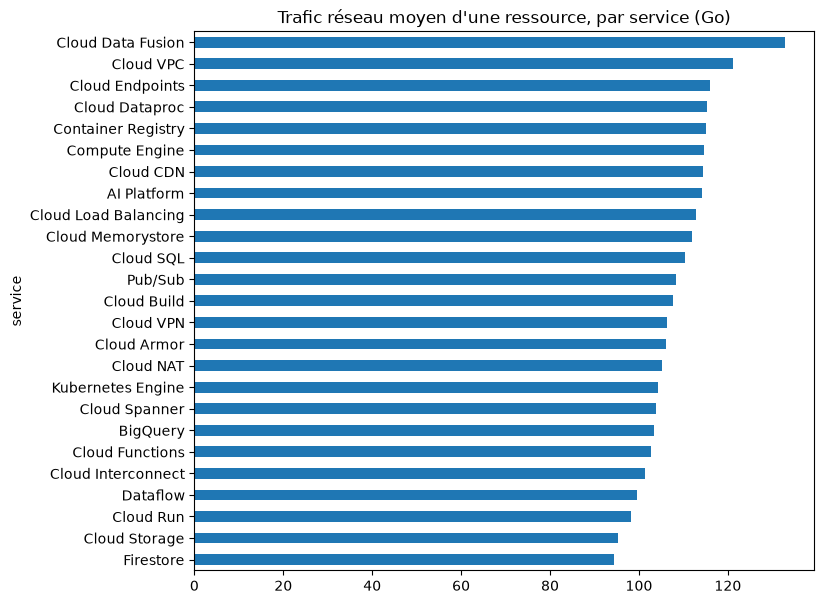

In [15]:
trafic_service.plot(
    kind="barh", figsize=(8, 7), title="Trafic réseau moyen d'une ressource, par service (Go)"
)

## 5. Trafic et coût

Est-ce que les ressources qui transfèrent le plus sont les plus chères ?

In [16]:
colonnes = ["cost_usd", "net_in_gb", "net_out_gb", "net_total_gb", "usage_quantity"]

df[colonnes].corr().round(2)

,cost_usd,net_in_gb,net_out_gb,net_total_gb,usage_quantity
cost_usd,1.00,-0.04,-0.03,-0.04,0.81
net_in_gb,-0.04,1.00,0.99,1.00,-0.01
net_out_gb,-0.03,0.99,1.00,1.00,-0.01
net_total_gb,-0.04,1.00,1.00,1.00,-0.01
usage_quantity,0.81,-0.01,-0.01,-0.01,1.00


<Axes: title={'center': 'Coût vs trafic réseau total'}, xlabel='net_total_gb', ylabel='cost_usd'>

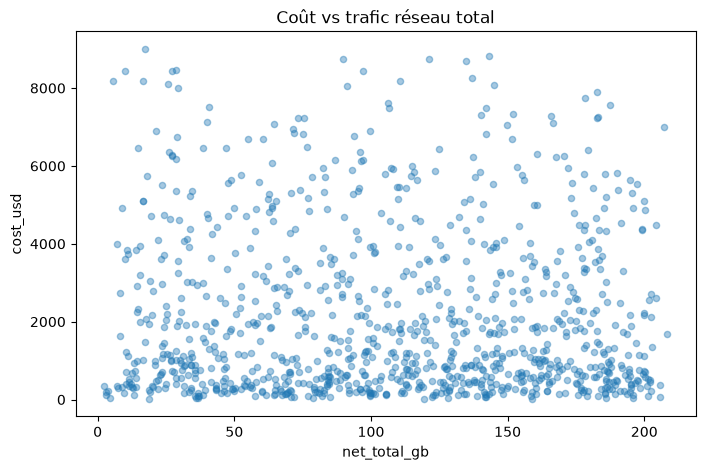

In [17]:
df.plot(
    kind="scatter", x="net_total_gb", y="cost_usd", alpha=0.4, figsize=(8, 5),
    title="Coût vs trafic réseau total",
)

Aucun lien, on a une corrélation entre `net_total_gb` et `cost_usd` qui est de -0,04, et le nuage de points n'a pas de forme.

## 6. Les plus gros transferts

In [18]:
df.sort_values("net_total_gb", ascending=False)[
    ["resource_id", "service", "region", "net_in_gb", "net_out_gb", "net_total_gb", "cost_usd"]
].head(10).round(1)

,resource_id,service,region,net_in_gb,net_out_gb,net_total_gb,cost_usd
187,res-3UA97I0E,Pub/Sub,europe-west1,99.7,108.8,208.5,1680.7
746,res-IJNXZ1NF,Container Registry,europe-north1,99.8,107.3,207.1,6996.7
304,res-ILI945FI,Cloud Run,australia-southeast1,99.7,106.2,205.9,368.1
232,res-X5BAACYY,Cloud Functions,us-west1,98.0,107.7,205.7,77.0
644,res-WGSVDFWN,Cloud VPN,europe-west3,98.2,106.2,204.4,4484.6
34,res-TDYG7ESV,Cloud NAT,europe-north1,98.2,106.2,204.4,2610.8
142,res-9DJ03H48,Container Registry,asia-east1,98.9,104.1,203.0,1356.5
479,res-89970DYQ,Cloud Interconnect,northamerica-northeast1,99.4,103.2,202.6,2707.7
360,res-MSIXWNK6,Cloud Run,southamerica-east1,99.8,102.8,202.5,212.8
202,res-6B2CMM2G,Cloud Interconnect,europe-west1,98.6,104.0,202.5,2116.1


Les 10 plus gros transferts sont tous autour de 200 Go, pour des coûts allant de 77 à 6 997 $, le volume de données n'explique pas le coût.

## Synthèse

- **Volume** : environ 108 Go de trafic par ressource en moyenne (52 entrant, 57
  sortant), avec de gros écarts mais rien d'aberrant
- **Sens** : le trafic est toujours majoritairement sortant (54 % en moyenne, jamais
  moins de 50 %). Entrant et sortant montent ensemble (corrélation 0,99)
- **Par service** : entre 94 et 133 Go de moyenne partout, aucun service ne se
  détache
- **Trafic et coût** : aucun lien (corrélation -0,04), confirmé par un nuage de points
  sans forme. Le réseau n'entre pas dans le calcul de `cost_usd`
- Les colonnes réseau décrivent une activité réelle des ressources, mais elles
  n'expliquent aucune partie de la facture de ce dataset